In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Straight Line

1000 1000


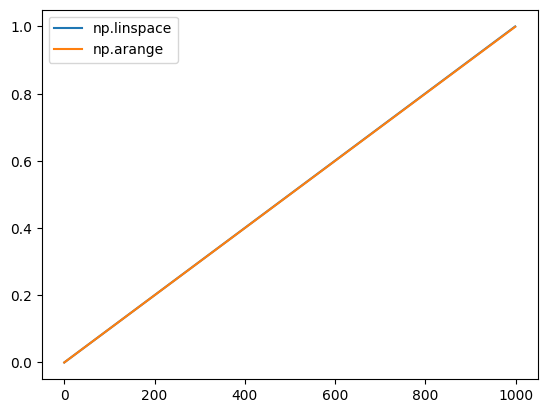

sum of x-y nan


C:\Users\setuthacker\AppData\Local\Temp\ipykernel_19020\910652743.py:11: RuntimeWarning: invalid value encountered in divide
  print("sum of x-y", np.sum(np.divide((x-y),x)))


In [ ]:
x = np.linspace(0, 1, 1000)
n = range(0, 1000)
y = np.arange(0, 1, 1/1000)
print(len(x),len(y))

plt.plot(n, x, label = "np.linspace")
plt.plot(n, y, label = "np.arange")
plt.legend()
plt.show()



Text(0.5, 1.0, 'Error between np.linspace and np.arange')

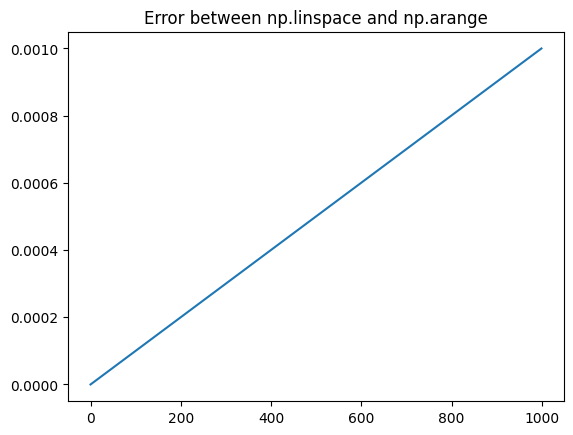

In [17]:
error = []
for i in range(len(x)):
    error.append((x[i]-y[i]))

error = np.array(error)

plt.plot(n, error)
plt.title("Error between np.linspace and np.arange")

### Signal in time domain

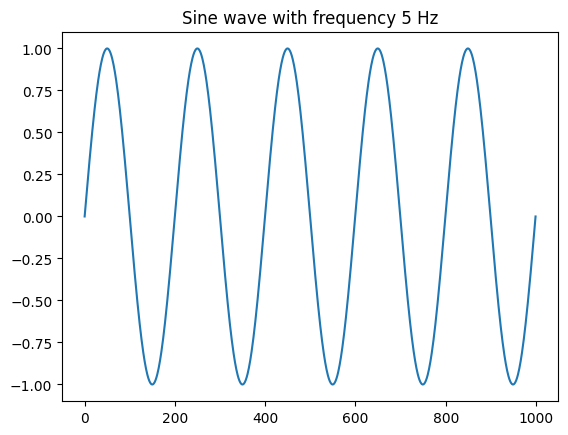

In [19]:
f_c = 5  # Frequency of the sine wave

x = np.linspace(0, 1, 1000)
y1 = np.sin(2 * np.pi * f_c * x)

plt.plot(n, y1)
plt.title(f"Sine wave with frequency {f_c} Hz")
plt.show()

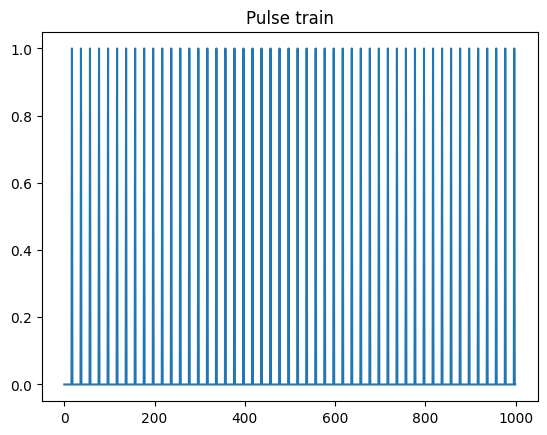

In [53]:
# pulse train

y2 = np.zeros(len(x))
y2[17::20] = 1  # Set every 20th sample to 1   

plt.plot(n, y2)
plt.title("Pulse train")
plt.show()

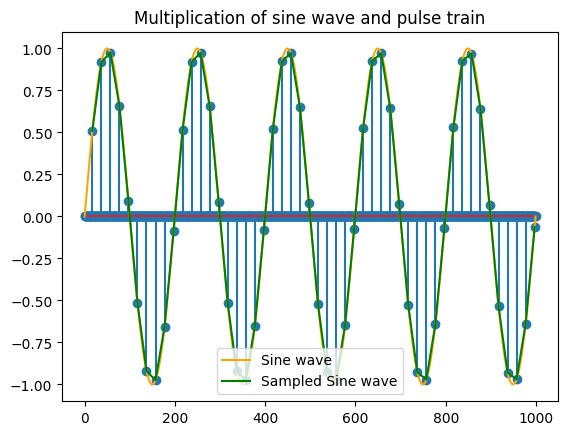

In [54]:
# multiplication of sine wave and pulse train
y3 = y1 * y2

mask = np.where(y3 != 0)

plt.stem(n, y3)
plt.plot(n,y1, label = "Sine wave", color = "orange")
plt.plot(mask[0], y3[mask], label = "Sampled Sine wave", color = "green")
plt.title("Multiplication of sine wave and pulse train")
plt.legend()
plt.show()

### Signal in Frequency domain

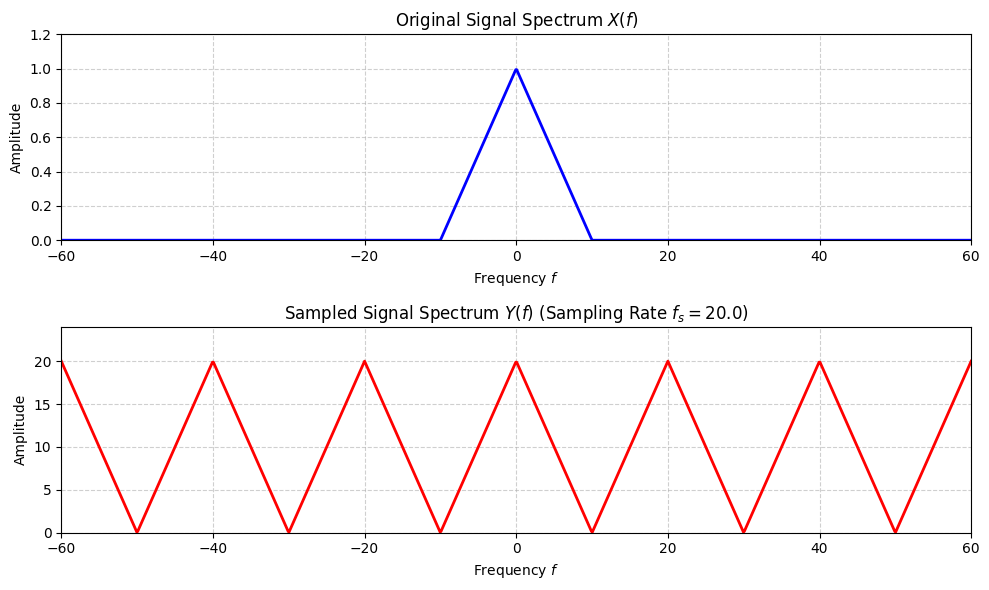

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Define Parameters
# ---------------------------------------------------------
fm = 10.0      # Maximum frequency of the original signal (bandlimit)
fs = 20.0      # Sampling frequency (fs > 2*fm to satisfy Nyquist)
Ts = 1.0 / fs  # Sampling period

# Create a frequency axis (analog frequency f)
f = np.linspace(-60, 60, 1000)

# ---------------------------------------------------------
# 2. Define the Original Signal Spectrum X(f)
# ---------------------------------------------------------
# We use a simple triangular pulse to represent the bandlimited spectrum 
# which is common in these textbook diagrams.
def X(freq, fm):
    # Triangle function: 1 at f=0, 0 at |f| >= fm
    return np.maximum(1 - np.abs(freq) / fm, 0)

X_f = X(f, fm)

# ---------------------------------------------------------
# 3. Model the Sampled Signal Spectrum Y(f)
# ---------------------------------------------------------
# Equation: Y(f) = (1/Ts) * SUM[ X(f - k/Ts) ] from k = -inf to inf
Y_f = np.zeros_like(f)

# Approximate infinity with a finite number of 'k' terms (e.g., -3 to 3)
k_values = range(-3, 4) 

for k in k_values:
    # Calculate the shift: k/Ts = k * fs
    shift = k * fs
    
    # Calculate the shifted spectrum: X(f - k*fs)
    X_shifted = X(f - shift, fm)
    
    # Add to the summation, scaled by 1/Ts
    Y_f += (1 / Ts) * X_shifted

# ---------------------------------------------------------
# 4. Plotting the Results
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Plot Original Spectrum X(f)
plt.subplot(2, 1, 1)
plt.plot(f, X_f, 'b', linewidth=2)
plt.title('Original Signal Spectrum $X(f)$')
plt.xlabel('Frequency $f$')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([-60, 60])
plt.ylim([0, 1.2])

# Plot Sampled Spectrum Y(f)
plt.subplot(2, 1, 2)
plt.plot(f, Y_f, 'r', linewidth=2)
plt.title(f'Sampled Signal Spectrum $Y(f)$ (Sampling Rate $f_s={fs}$)')
plt.xlabel('Frequency $f$')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim([-60, 60])
# The amplitude is scaled by 1/Ts (which is fs). 
plt.ylim([0, (1/Ts) * 1.2])

plt.tight_layout()
plt.show()

### Infinte Impulse Response (IIR)  

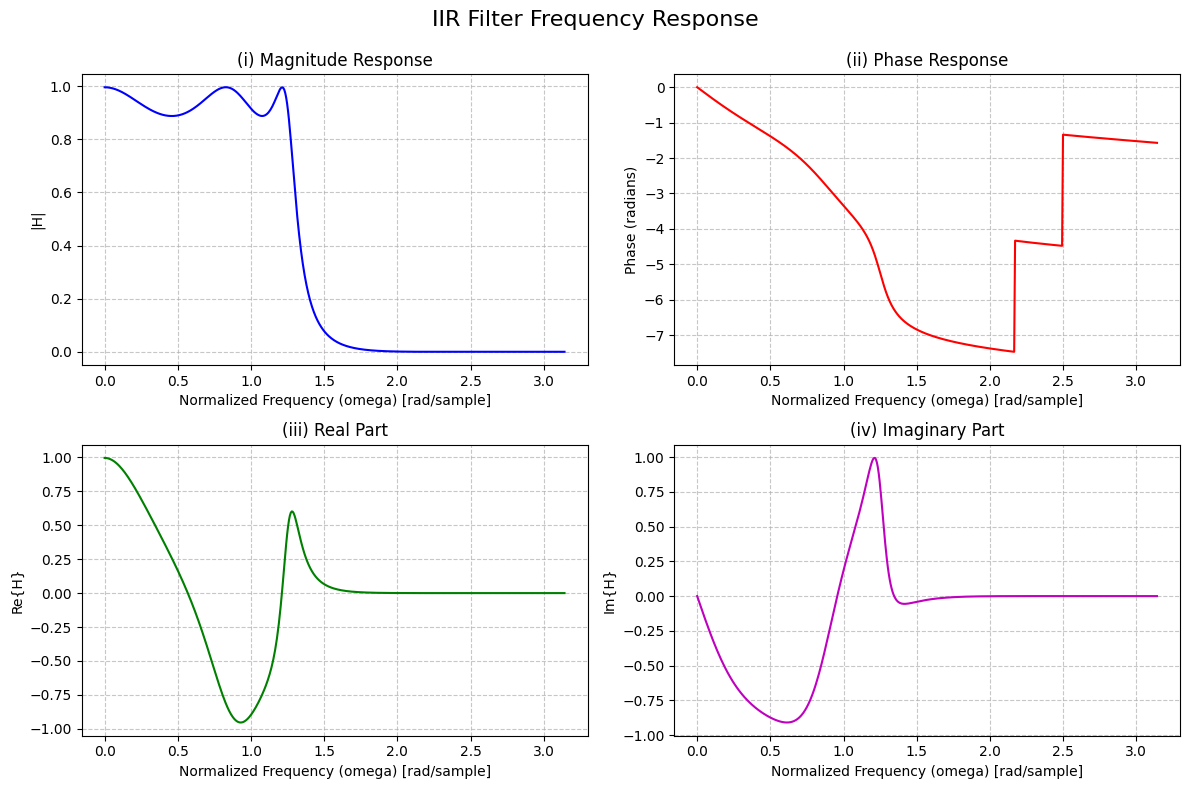

In [60]:
import numpy as np

def calculate_H(w):
    """
    Calculates the frequency response H(e^jw) for a given array of frequencies w.
    w: numpy array of frequencies (in radians/sample)
    """
    # e^(-jw) and e^(-j2w) terms
    exp_jw1 = np.exp(-1j * w)
    exp_jw2 = np.exp(-2j * w)  # which is also exp_jw1**2
    
    # Section 1 (First-order section)
    num1 = 1 + exp_jw1
    den1 = 1 - 0.6386 * exp_jw1
    term1 = num1 / den1
    
    # Section 2 (Second-order section / biquad)
    num2 = 1 + 1.5975 * exp_jw1 + exp_jw2
    den2 = 1 - 0.9621 * exp_jw1 + 0.5708 * exp_jw2
    term2 = num2 / den2
    
    # Section 3 (Second-order section / biquad)
    num3 = 1 + 1.12724 * exp_jw1 + exp_jw2
    den3 = 1 - 0.5811 * exp_jw1 + 0.8547 * exp_jw2
    term3 = num3 / den3
    
    # Overall Gain
    gain = 0.0124
    
    # Final H(e^jw) is the product of all cascaded sections and the gain
    H = gain * term1 * term2 * term3
    
    return H

# Example usage:
# Generate an array of frequencies from 0 to pi
w = np.linspace(0, np.pi, 500)

# Calculate the frequency response
H = calculate_H(w)

# You can now easily extract the parts needed for the plots:
magnitude = np.abs(H)
phase = np.angle(H)
real_part = np.real(H)
imag_part = np.imag(H)

# 6. Create the plots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('IIR Filter Frequency Response', fontsize=16)

# (i) Magnitude Response
axs[0, 0].plot(w, magnitude, 'b')
axs[0, 0].set_title('(i) Magnitude Response')
axs[0, 0].set_xlabel('Normalized Frequency (omega) [rad/sample]')
axs[0, 0].set_ylabel('|H|')
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# (ii) Phase Response
axs[0, 1].plot(w, np.unwrap(phase), 'r')
axs[0, 1].set_title('(ii) Phase Response')
axs[0, 1].set_xlabel('Normalized Frequency (omega) [rad/sample]')
axs[0, 1].set_ylabel('Phase (radians)')
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# (iii) Real Part
axs[1, 0].plot(w, real_part, 'g')
axs[1, 0].set_title('(iii) Real Part')
axs[1, 0].set_xlabel('Normalized Frequency (omega) [rad/sample]')
axs[1, 0].set_ylabel('Re{H}')
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# (iv) Imaginary Part
axs[1, 1].plot(w, imag_part, 'm')
axs[1, 1].set_title('(iv) Imaginary Part')
axs[1, 1].set_xlabel('Normalized Frequency (omega) [rad/sample]')
axs[1, 1].set_ylabel('Im{H}')
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout for better spacing and display
plt.tight_layout()
plt.subplots_adjust(top=0.9) 
plt.show()

### Chirp rate

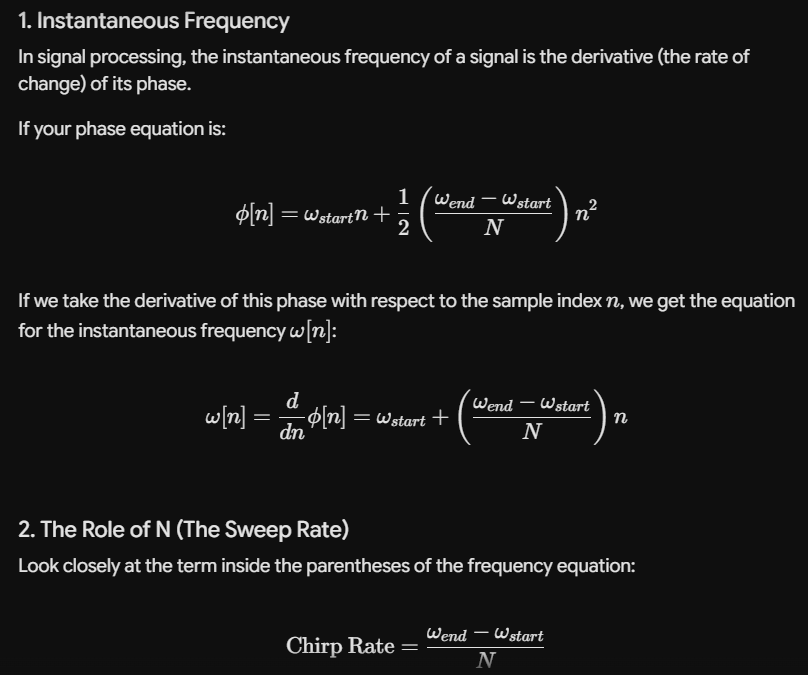

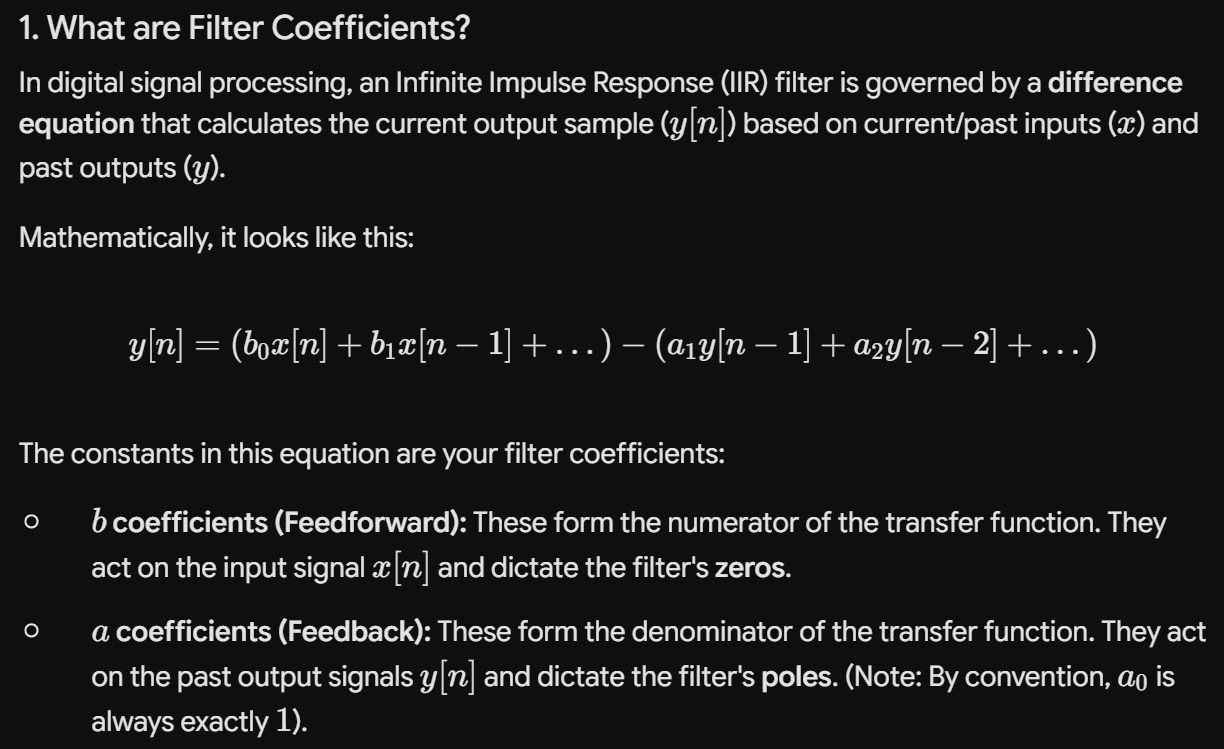

w_start: 0.0 w_end: 1.9634954084936207


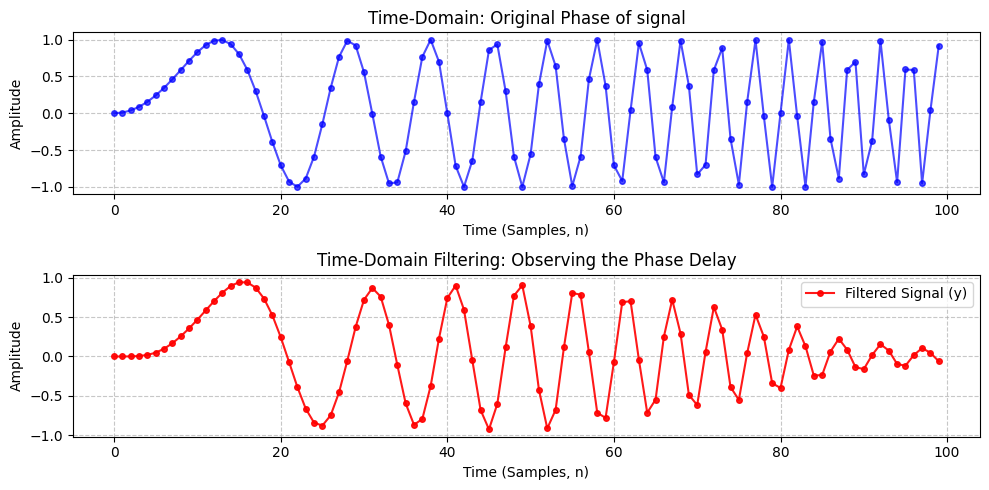

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# 1. Define Filter Coefficients
# We multiply (convolve) the cascaded sections to get the final numerator (b) 
# and denominator (a) coefficients for the time-domain difference equation.
b1, a1 = [1, 1], [1, -0.6386]
b2, a2 = [1, 1.5975, 1], [1, -0.9621, 0.5708]
b3, a3 = [1, 1.12724, 1], [1, -0.5811, 0.8547]
gain = 0.0124

# Convolve arrays to multiply the polynomials
b = gain * np.convolve(b1, np.convolve(b2, b3))
a = np.convolve(a1, np.convolve(a2, a3))

# 2. Generate a signal crossing w = 0.75
# We use a 100-sample chirp that sweeps from w=0.2 to w=1.2 rad/sample
N = 100
n = np.arange(N)
BW = 1.2e9
fs = 3.2*BW
w_start, w_end = 2*np.pi*0/fs , 2*np.pi*BW/fs
# w_start, w_end = 0.2 , 1.2

print("w_start:", w_start, "w_end:", w_end)

# x_input = np.exp(1j * (w_start * n + 0.5 * ((w_end - w_start) / N) * n**2))
x_input = np.sin((w_start * n + 0.5 * ((w_end - w_start) / N) * n**2))

# Calculate the instantaneous phase for the chirp
# phase_n = w_start * n + 0.5 * ((w_end - w_start) / N) * n**2
# x_input = np.sin(phase_n)

# 3. Apply the digital filter
y_output = lfilter(b, a, x_input)

# 4. Plot to visualize the time delay
plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
# We plot the signals with markers to clearly see the discrete samples
plt.plot(n, x_input, 'bo-', label='Input Signal (x)', markersize=4, alpha=0.7)
plt.title('Time-Domain: Original Phase of signal')
plt.xlabel('Time (Samples, n)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(2, 1, 2)
plt.plot(n, y_output, 'ro-', label='Filtered Signal (y)', markersize=4, alpha=0.9)
plt.title('Time-Domain Filtering: Observing the Phase Delay')
plt.xlabel('Time (Samples, n)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--', alpha=0.7)


plt.legend()
plt.tight_layout()
plt.show()

### Random Sampling

Reconstruction Fidelity (Correlation): 98.27%
Uniform Sampling Rate: 2560.0 MSPS
Random Sampling Rate (Avg): 1600.0 MSPS (Saving 37.5% data)


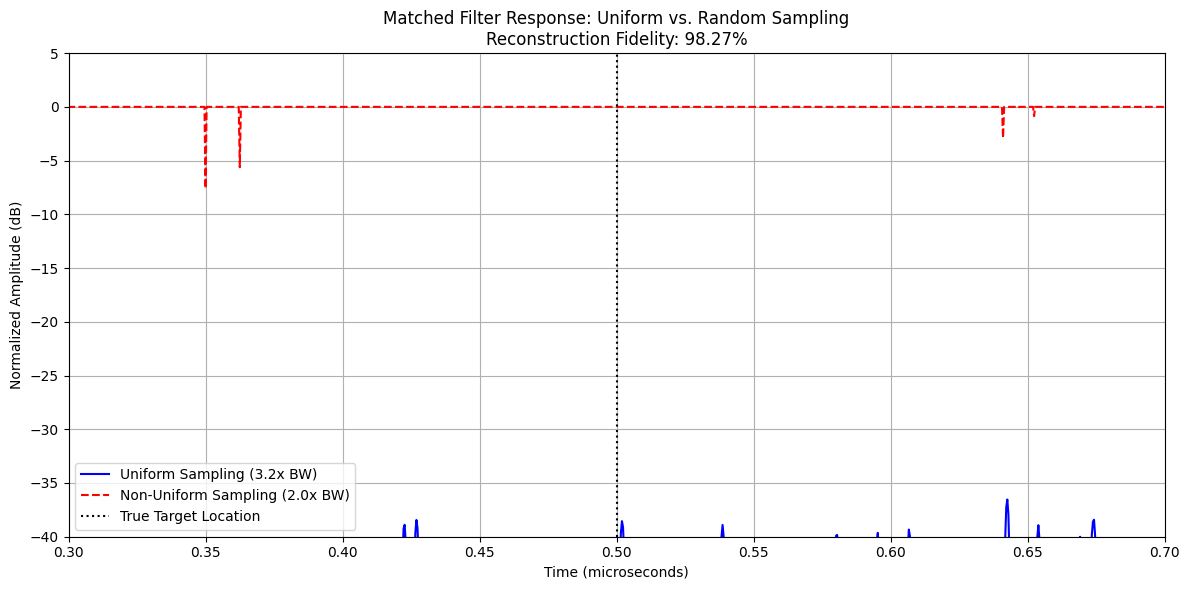

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import correlate

# ==========================================
# 1. Radar & Signal Parameters
# ==========================================
BW = 800e6                # Bandwidth: 800 MHz
T_pulse = 1e-6            # Pulse width: 1 microsecond
K = BW / T_pulse          # Chirp rate

# Sampling Rates based on assumptions
Fs_uni = 3.2 * BW         # Uniform sampling rate (2560 MHz)
Fs_nu_avg = 2.0 * BW      # Average non-uniform sampling rate (1600 MHz)
Fs_analog = 10 * BW       # Highly oversampled "analog" ground truth (8000 MHz)

# Time axis for the continuous "analog" signal
t_min, t_max = -0.5 * T_pulse, 2.0 * T_pulse
t_analog = np.arange(t_min, t_max, 1/Fs_analog)

# ==========================================
# 2. Generate Transmitted and Received Signals
# ==========================================
# Baseband Linear FM Chirp (Transmit Pulse)
tx_pulse = np.zeros_like(t_analog, dtype=complex)
pulse_idx = (t_analog >= -T_pulse/2) & (t_analog <= T_pulse/2)
tx_pulse[pulse_idx] = np.exp(1j * np.pi * K * t_analog[pulse_idx]**2)

# Simulate received signal with a delay (target at 0.5 us)
target_delay = 0.5e-6
rx_analog = np.zeros_like(t_analog, dtype=complex)
rx_idx = (t_analog >= -T_pulse/2 + target_delay) & (t_analog <= T_pulse/2 + target_delay)
rx_analog[rx_idx] = np.exp(1j * np.pi * K * (t_analog[rx_idx] - target_delay)**2)

# Add complex Gaussian white noise (SNR = 10 dB)
noise_power = 0.1
rx_analog += np.sqrt(noise_power/2) * (np.random.randn(len(t_analog)) + 1j * np.random.randn(len(t_analog)))

# ==========================================
# 3. ADC Sampling Implementation
# ==========================================
# A. Uniform Sampling (Fs = 3.2 * BW)
t_uni = np.arange(t_min, t_max, 1/Fs_uni)
interp_real = interp1d(t_analog, np.real(rx_analog), kind='cubic')
interp_imag = interp1d(t_analog, np.imag(rx_analog), kind='cubic')
rx_uni = interp_real(t_uni) + 1j * interp_imag(t_uni)

# B. Non-Uniform (Random) Sampling (Average Fs = 2.0 * BW)
# We simulate this by taking a uniform grid and applying random jitter to the intervals
t_nu_ideal = np.arange(t_min, t_max, 1/Fs_nu_avg)
jitter_max = (1/Fs_nu_avg) * 0.4 # max jitter is 40% of the interval
jitter = np.random.uniform(-jitter_max, jitter_max, len(t_nu_ideal))
t_nu = t_nu_ideal + jitter

# Sample the analog signal at the random timestamps
rx_nu = interp_real(t_nu) + 1j * interp_imag(t_nu)

# ==========================================
# 4. Reconstruction & Matched Filtering
# ==========================================
# To do an FFT-based matched filter (standard SAR processing), 
# we must interpolate the random samples back onto a uniform grid.
# We will interpolate it back to the Fs_uni grid for direct comparison.
reconstruct_real = interp1d(t_nu, np.real(rx_nu), bounds_error=False, fill_value=0, kind='linear')
reconstruct_imag = interp1d(t_nu, np.imag(rx_nu), bounds_error=False, fill_value=0, kind='linear')
rx_reconstructed = reconstruct_real(t_uni) + 1j * reconstruct_imag(t_uni)

# Generate Reference Signal for Matched Filter at Fs_uni
ref_uni = np.zeros_like(t_uni, dtype=complex)
ref_idx = (t_uni >= -T_pulse/2) & (t_uni <= T_pulse/2)
ref_uni[ref_idx] = np.exp(1j * np.pi * K * t_uni[ref_idx]**2)

# Apply Matched Filter (Cross-Correlation)
mf_uni = correlate(rx_uni, ref_uni, mode='same')
mf_nu  = correlate(rx_reconstructed, ref_uni, mode='same')

# Normalize for plotting
mf_uni_mag = np.abs(mf_uni)
mf_nu_mag = np.abs(mf_nu)
mf_uni_mag /= np.max(mf_uni_mag)
mf_nu_mag /= np.max(mf_uni_mag) # Normalize relative to uniform peak

# ==========================================
# 5. Calculate % of Reconstruction
# ==========================================
# We calculate the Pearson Correlation Coefficient between the two MF outputs
# to determine the fidelity percentage of the reconstructed signal.
correlation_matrix = np.corrcoef(mf_uni_mag, mf_nu_mag)
reconstruction_percent = correlation_matrix[0, 1] * 100

print(f"Reconstruction Fidelity (Correlation): {reconstruction_percent:.2f}%")
print(f"Uniform Sampling Rate: {Fs_uni/1e6} MSPS")
print(f"Random Sampling Rate (Avg): {Fs_nu_avg/1e6} MSPS (Saving {(1 - Fs_nu_avg/Fs_uni)*100:.1f}% data)")

# ==========================================
# 6. Plotting
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(t_uni * 1e6, 20 * np.log10(np.clip(mf_uni_mag, 1e-10, 1)), label='Uniform Sampling (3.2x BW)', color='blue')
plt.plot(t_uni * 1e6, 20 * np.log10(np.clip(mf_nu_mag, 1e-10, 1)), label='Non-Uniform Sampling (2.0x BW)', color='red', linestyle='--')
plt.axvline(target_delay * 1e6, color='black', linestyle=':', label='True Target Location')

plt.title(f"Matched Filter Response: Uniform vs. Random Sampling\nReconstruction Fidelity: {reconstruction_percent:.2f}%")
plt.xlabel("Time (microseconds)")
plt.ylabel("Normalized Amplitude (dB)")
plt.xlim(0.3, 0.7)
plt.ylim(-40, 5)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import correlate
from scipy.signal.windows import boxcar
import tqdm

distortion_error_storage = []
pslr_uni_storage = []
pslr_nu_storage = []

# ==========================================
# 1. System Parameters
# ==========================================
BW = 800e6                # Bandwidth: 800 MHz
T_pulse = 9.09e-6            # Pulse width: 1 us
K = BW / T_pulse          # Chirp slope

Fs_uni = 3.2 * BW         # Uniform sampling
Fs_nu_avg = 2.0 * BW      # Non-uniform average sampling
Fs_analog = 15 * BW       # Highly oversampled ground truth

t_min, t_max = -0.5 * T_pulse, 0.5 * T_pulse
t_analog = np.arange(t_min, t_max, 1/Fs_analog)

# ==========================================
# 2. Generate Signals (Noiseless to isolate sampling distortion)
# ==========================================
# Transmit Pulse
tx_pulse = np.zeros_like(t_analog, dtype=complex)
pulse_idx = (t_analog >= -T_pulse/2) & (t_analog <= T_pulse/2)
tx_pulse[pulse_idx] = np.exp(1j * np.pi * K * t_analog[pulse_idx]**2)

# Received Signal (Target at t=0 for easy centering)
rx_analog = tx_pulse.copy() 

# ==========================================
# 3. Apply ADC Sampling
# ==========================================
# Uniform
t_uni = np.arange(t_min, t_max, 1/Fs_uni)
# interp_r = interp1d(t_analog, np.real(rx_analog), kind='cubic')
# interp_i = interp1d(t_analog, np.imag(rx_analog), kind='cubic')
interp_r = interp1d(t_analog, np.real(rx_analog), kind='cubic', bounds_error=False, fill_value=0)
interp_i = interp1d(t_analog, np.imag(rx_analog), kind='cubic', bounds_error=False, fill_value=0)
rx_uni = interp_r(t_uni) + 1j * interp_i(t_uni)

for i in tqdm.tqdm(range(100)):

    # Non-Uniform (Random Jitter)
    t_nu_ideal = np.arange(t_min, t_max, 1/Fs_nu_avg)
    jitter_max = (1/Fs_nu_avg) * 0.45 
    jitter = np.random.uniform(-jitter_max, jitter_max, len(t_nu_ideal))
    t_nu = t_nu_ideal + jitter

    rx_nu = interp_r(t_nu) + 1j * interp_i(t_nu)

    # Reconstruct Non-Uniform back to Uniform grid for Matched Filtering
    rec_r = interp1d(t_nu, np.real(rx_nu), bounds_error=False, fill_value=0, kind='linear')
    rec_i = interp1d(t_nu, np.imag(rx_nu), bounds_error=False, fill_value=0, kind='linear')
    rx_reconstructed = rec_r(t_uni) + 1j * rec_i(t_uni)

    # ==========================================
    # 4. Matched Filtering
    # ==========================================
    ref_uni = np.zeros_like(t_uni, dtype=complex)
    ref_idx = (t_uni >= -T_pulse/2) & (t_uni <= T_pulse/2)
    ref_uni[ref_idx] = np.exp(1j * np.pi * K * t_uni[ref_idx]**2)

    mf_uni = correlate(rx_uni, ref_uni, mode='same')
    mf_nu = correlate(rx_reconstructed, ref_uni, mode='same')

    # Normalize
    mf_uni_mag = np.abs(mf_uni) / np.max(np.abs(mf_uni))
    mf_nu_mag = np.abs(mf_nu) / np.max(np.abs(mf_nu))

    # Theoretical Ideal Sinc
    ideal_sinc = np.abs(np.sinc(BW * t_uni)) 
    # Note: np.sinc in python is defined as sin(pi*x)/(pi*x)

    # ==========================================
    # 5. Distortion Calculations
    # ==========================================
    # Isolate the main pulse area for metric calculations (+/- 5 nanoseconds)
    zoom_mask = (t_uni >= -5e-9) & (t_uni <= 5e-9)

    # 1. Mean Squared Error (MSE) against the ideal sinc
    mse_uni = np.mean((mf_uni_mag[zoom_mask] - ideal_sinc[zoom_mask])**2)
    mse_nu = np.mean((mf_nu_mag[zoom_mask] - ideal_sinc[zoom_mask])**2)
    distortion_increase = (mse_nu / mse_uni) if mse_uni > 0 else float('inf')

    # 2. Peak Sidelobe Ratio (PSLR)
    # Find the highest peak outside the main lobe (+/- 1.5/BW)
    main_lobe_width = 1.5 / BW
    sidelobe_mask = (np.abs(t_uni) > main_lobe_width) & zoom_mask
    pslr_uni = 20 * np.log10(np.max(mf_uni_mag[sidelobe_mask]))
    pslr_nu = 20 * np.log10(np.max(mf_nu_mag[sidelobe_mask]))

    distortion_error_storage.append(distortion_increase)
    pslr_uni_storage.append(pslr_uni)
    pslr_nu_storage.append(pslr_nu)

# print(f"--- Distortion Metrics ---")
# print(f"Uniform Sampling MSE:     {mse_uni:.6f}")
# print(f"Non-Uniform Sampling MSE: {mse_nu:.6f} ({distortion_increase:.1f}x higher error)")
# print(f"Ideal PSLR:              -13.26 dB")
# print(f"Uniform PSLR:            {pslr_uni:.2f} dB")
# print(f"Non-Uniform PSLR:        {pslr_nu:.2f} dB")

print(f"Average Distortion Increase (Non-Uniform vs Uniform): {np.mean(distortion_error_storage):.2f}x")
print(f"Ideal PSLR:               -13.26 dB")
print(f"Average Uniform PSLR:     {np.mean(pslr_uni_storage):.2f} dB")
print(f"Average Non-Uniform PSLR: {np.mean(pslr_nu_storage):.2f} dB")

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:02<00:00, 40.31it/s]

Average Distortion Increase (Non-Uniform vs Uniform): 1.45x
Ideal PSLR:               -13.26 dB
Average Uniform PSLR:     -13.99 dB
Average Non-Uniform PSLR: -15.38 dB


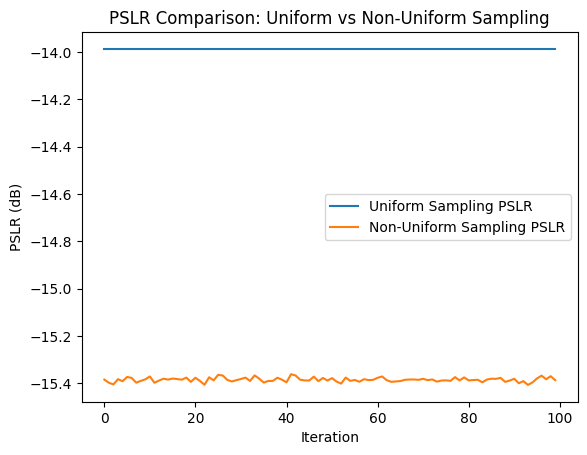

In [99]:
plt.plot(range(100),pslr_uni_storage)
plt.plot(range(100), pslr_nu_storage)
plt.title("PSLR Comparison: Uniform vs Non-Uniform Sampling")
plt.xlabel("Iteration")
plt.ylabel("PSLR (dB)")
plt.legend(["Uniform Sampling PSLR", "Non-Uniform Sampling PSLR"])
plt.show()

### DFT

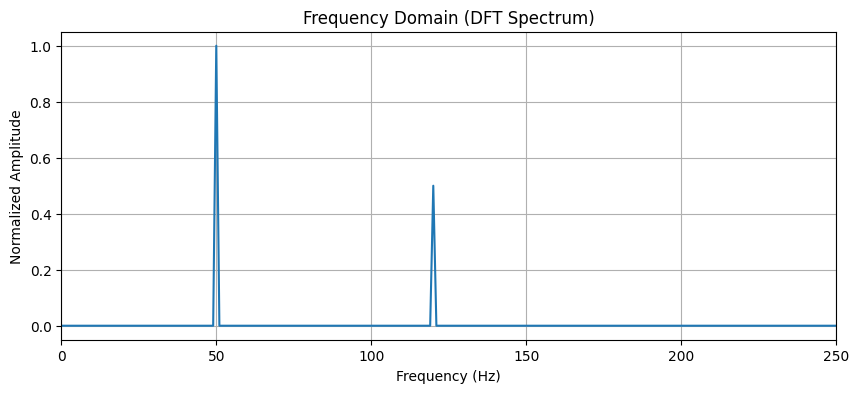

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a dummy signal (Example: 50 Hz and 120 Hz sine waves)
sampling_rate = 1000  # Hz (Number of samples per second)
duration = 1.0        # Seconds
N = int(sampling_rate * duration)  # Total number of samples

time = np.linspace(0, duration, N, endpoint=False)
# Signal composed of a 50Hz wave and a 120Hz wave
signal = np.sin(2 * np.pi * 50 * time) + 0.5 * np.sin(2 * np.pi * 120 * time)

# 2. Compute the DFT using the FFT algorithm
dft_output = np.fft.fft(signal)

# 3. Calculate the corresponding frequencies
frequencies = np.fft.fftfreq(N, dft_interval := 1/sampling_rate)

# 4. Normalize magnitude and isolate positive frequencies (Symmetry)
# Multiplying by 2/N normalizes the amplitude for real-valued signals
magnitude = np.abs(dft_output) * 2 / N 

# Only keep the first half (positive frequencies up to the Nyquist limit)
half_N = N // 2
pos_frequencies = frequencies[:half_N]
pos_magnitude = magnitude[:half_N]

# 5. Plot the result
plt.figure(figsize=(10, 4))
plt.plot(pos_frequencies, pos_magnitude)
plt.title("Frequency Domain (DFT Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.grid(True)
plt.xlim(0, 250)  # Zooming into the relevant frequency zone
plt.show()


To understand this concept deeply, we need to bridge algebra, geometry, and a bit of physics. The "unit circle" in this context refers to the **complex unit circle**, which is the fundamental geometric playground for digital signal processing.

Here is the in-depth breakdown of how this works.

#### 1. The Complex Plane and the Unit Circle

In standard geometry, you have an X-Y grid. In signal processing, we use the **complex plane**, where:

* The **horizontal axis** is the Real part ($\text{Re}$).
* The **vertical axis** is the Imaginary part ($\text{Im}$).

The **unit circle** is simply a circle drawn on this plane with its center at the origin $(0,0)$ and a radius of exactly $1$.

Every point sitting on the edge of this circle can be represented by a vector (an arrow starting from the origin). Because the radius is 1, every vector on this circle has a length (magnitude) of exactly 1. The only thing that distinguishes one point from another is its **angle**.

#### 2. Euler's Formula: The Mathematical Engine

Euler's formula provides the mathematical language to describe any point on this unit circle:


$$e^{j\theta} = \cos(\theta) + j\sin(\theta)$$

* $\theta$ (theta) is the angle in radians.
* $\cos(\theta)$ gives you the horizontal (Real) coordinate.
* $\sin(\theta)$ gives you the vertical (Imaginary) coordinate.

Therefore, the term $e^{j\theta}$ is not just an abstract number; it is a **rotating vector** (often called a phasor) of length 1 pointing at an angle $\theta$.

#### 3. Slicing the Circle (The DFT Exponent)

Let's look at the specific mathematical term from the previous problem:


$$e^{j2\pi \frac{n(l-k)}{N}}$$

We can break down the angle $\theta = 2\pi \frac{n(l-k)}{N}$ into understandable pieces:

* **$2\pi$:** This represents one full, complete rotation around the circle ($360^\circ$).
* **$/N$:** This divides the full circle into $N$ perfectly equal slices (like slicing a pizza into $N$ pieces).
* **$n$:** As $n$ ticks forward from $0$ to $N-1$, it acts as a counter, stepping from one slice to the next.
* **$(l-k)$:** This is an integer that dictates the "stride" or "speed" of rotation. If $(l-k) = 1$, the vector steps one slice at a time. If $(l-k) = 2$, it jumps two slices at a time.

#### 4. Why the Vectors Cancel to Zero (Visual Intuition)

When we compute the DFT, we are **summing** these vectors together for all values of $n$ from $0$ to $N-1$.

Imagine you are calculating a 4-point DFT ($N=4$), and the stride $(l-k) = 1$. As $n$ goes from $0$ to $3$, your formula generates four vectors:

1. $n=0$: Points at $0^\circ$ (Right)
2. $n=1$: Points at $90^\circ$ (Up)
3. $n=2$: Points at $180^\circ$ (Left)
4. $n=3$: Points at $270^\circ$ (Down)

If you add these four vectors together—Right plus Left, Up plus Down—they completely cancel each other out. The net result is perfectly $0$.

**The Physical Analogy:** Imagine $N$ people standing equally spaced around the edge of a circular ring, all pulling a central rope toward themselves with exactly the same amount of force. Because they are evenly spaced and pulling equally, the central ring will not move a single millimeter. The sum of the forces is zero.

#### 5. The Rigorous Mathematical Proof (Geometric Series)

We can prove this visual intuition using standard algebra. The summation we are trying to solve is:


$$\sum_{n=0}^{N-1} \left( e^{j2\pi(l-k)/N} \right)^n$$

This is a finite geometric series of the form $\sum_{n=0}^{N-1} r^n$, where our common ratio $r = e^{j2\pi(l-k)/N}$.
The mathematical formula for the sum of a finite geometric series is:


$$\text{Sum} = \frac{1 - r^N}{1 - r}$$

Let's look closely at the numerator: $1 - r^N$.
If we plug our $r$ back in and apply the exponent $N$, the $N$ in the exponent and the $N$ in the denominator cancel out:


$$r^N = \left( e^{j2\pi(l-k)/N} \right)^N = e^{j2\pi(l-k)}$$

Because $(l-k)$ is guaranteed to be a non-zero integer, $e^{j2\pi(l-k)}$ represents a rotation by a perfect, whole number of full circles. Whether you rotate $360^\circ$, $720^\circ$, or $1080^\circ$, you always land exactly back where you started: facing dead right on the real axis at the value of $1$.

Therefore:


$$e^{j2\pi(l-k)} = 1$$

Substitute this back into the numerator of our sum formula:


$$\text{Sum} = \frac{1 - 1}{1 - r} = \frac{0}{1 - r} = 0$$

*(Note: The denominator $1 - r$ is not zero because $(l-k)$ is not a multiple of $N$, meaning $r$ itself is not $1$).*

This proves mathematically what we know visually: summing evenly spaced complex vectors around the unit circle always results in exact cancellation.

100%|██████████| 349/349 [00:00<00:00, 2015.01it/s]


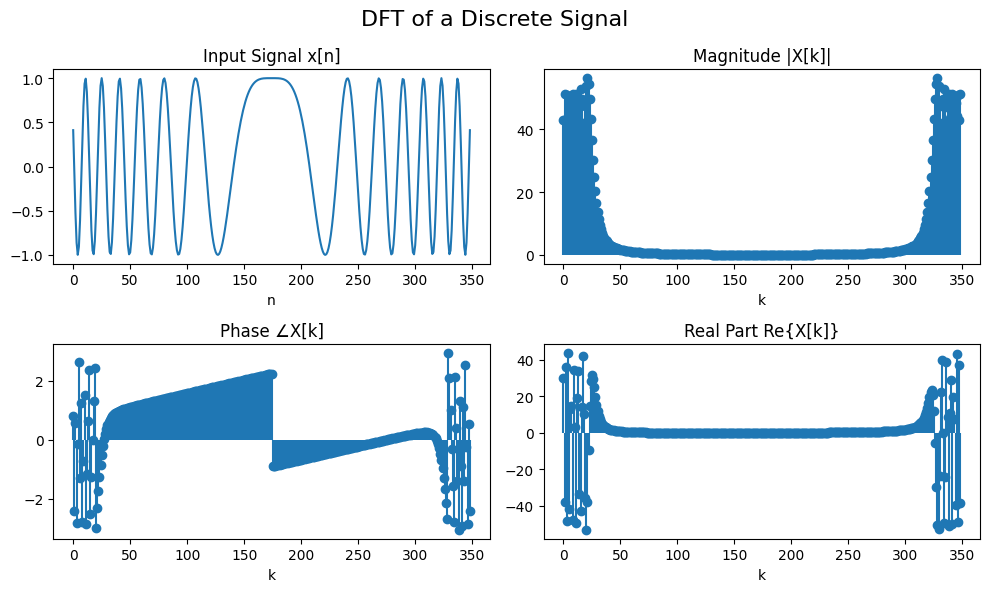

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Input sequence (Impulse at n=3)

BW = 12e6  # Bandwidth of the chirp
Tp = 9.09e-6
chirp_rate = BW/Tp  # Chirp rate (k = BW/Tp)
Fs = 3.2*BW

# 2. Correct Time Vector
# Number of points = Duration * Sampling Frequency
num_samples = int(Tp * Fs) 
n = np.linspace(-Tp/2, Tp/2, num_samples)

# x = np.sin(2 * np.pi * 5 * n)  # Example: 5 Hz sine wave
# x = np.cos(2 * np.pi * 20 * n)  # Example: 5 Hz sine wave
x = np.exp(1j * np.pi * chirp_rate /2 * n**2)  # Example: 5 Hz sine wave

def W_N(k, n, N):
    return np.exp(-1j * 2 * np.pi * k * n / N)

X_K = []
for k in tqdm(range(len(x))):
    sum_val = 0
    for n in range(len(x)):
        sum_val += x[n] * W_N(k, n, len(x))
    X_K.append(sum_val)

fig, ax = plt.subplots(2, 2, figsize=(10, 6))

fig.suptitle("DFT of a Discrete Signal", fontsize=16)

# (1) Input Signal
ax[0, 0].plot(range(len(x)), np.real(x))
ax[0, 0].set_title("Input Signal x[n]")
ax[0, 0].set_xlabel("n")

# (2) Magnitude
ax[0, 1].stem(range(len(X_K)), np.abs(X_K), basefmt=" ")
ax[0, 1].set_title("Magnitude |X[k]|")
ax[0, 1].set_xlabel("k")

# (3) Phase
ax[1, 0].stem(range(len(X_K)), np.angle(X_K), basefmt=" ")
ax[1, 0].set_title("Phase ∠X[k]")
ax[1, 0].set_xlabel("k")

# (4) Real Part
ax[1, 1].stem(range(len(X_K)), np.real(X_K), basefmt=" ")
ax[1, 1].set_title("Real Part Re{X[k]}")
ax[1, 1].set_xlabel("k")

plt.tight_layout()
plt.show()

  0%|          | 0/349 [00:00<?, ?it/s]

100%|██████████| 349/349 [00:00<00:00, 2364.10it/s]


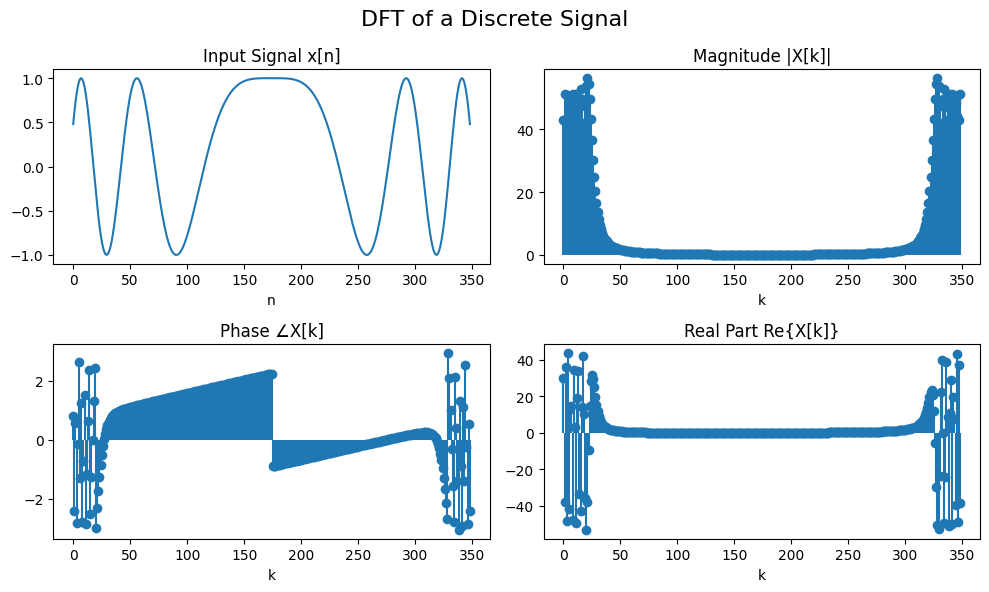

In [20]:
BW = 12e6  # Bandwidth of the chirp
Tp = 9.09e-6
chirp_rate = BW/Tp  # Chirp rate (k = BW/Tp)
Fs = 3.2*BW

# 2. Correct Time Vector
# Number of points = Duration * Sampling Frequency
num_samples = int(Tp * Fs) 
n = np.linspace(-Tp/2, Tp/2, num_samples)

# x = np.sin(2 * np.pi * 5 * n)  # Example: 5 Hz sine wave
# x = np.cos(2 * np.pi * 20 * n)  # Example: 5 Hz sine wave
x = np.exp(1j * chirp_rate /2 * n**2)  # Example: 5 Hz sine wave

def dft_compute(x):
    N = len(x)
    X_K = []
    for k in tqdm(range(N)):
        sum_val = 0
        for n in range(N):
            sum_val += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
        X_K.append(sum_val)
    return np.array(X_K)

y = dft_compute(x)

fig, ax = plt.subplots(2, 2, figsize=(10, 6))

fig.suptitle("DFT of a Discrete Signal", fontsize=16)

# (1) Input Signal
ax[0, 0].plot(range(len(x)), np.real(x))
ax[0, 0].set_title("Input Signal x[n]")
ax[0, 0].set_xlabel("n")

# (2) Magnitude
ax[0, 1].stem(range(len(X_K)), np.abs(X_K), basefmt=" ")
ax[0, 1].set_title("Magnitude |X[k]|")
ax[0, 1].set_xlabel("k")

# (3) Phase
ax[1, 0].stem(range(len(X_K)), np.angle(X_K), basefmt=" ")
ax[1, 0].set_title("Phase ∠X[k]")
ax[1, 0].set_xlabel("k")

# (4) Real Part
ax[1, 1].stem(range(len(X_K)), np.real(X_K), basefmt=" ")
ax[1, 1].set_title("Real Part Re{X[k]}")
ax[1, 1].set_xlabel("k")

plt.tight_layout()
plt.show()

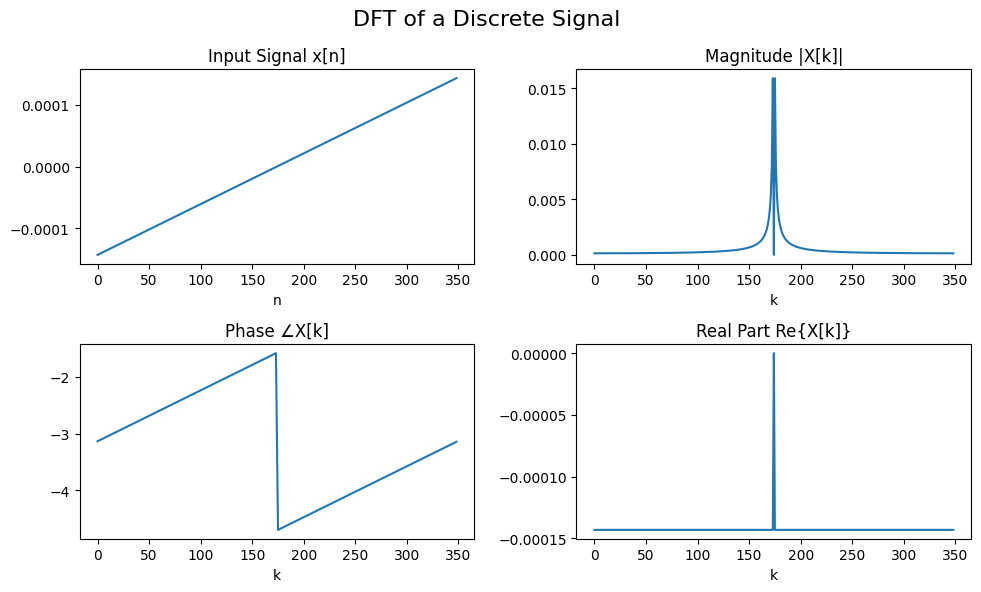

In [36]:
BW = 12e6  # Bandwidth of the chirp
Tp = 9.09e-6
chirp_rate = BW/Tp  # Chirp rate (k = BW/Tp)
Fs = 3.2*BW

# 2. Correct Time Vector
# Number of points = Duration * Sampling Frequency
num_samples = int(Tp * Fs) 
n = np.linspace(-Tp/2, Tp/2, num_samples)
# x = np.sin(2 * np.pi * 5 * n)  # Example: 5 Hz sine wave
# x = np.cos(2 * np.pi * 20 * n)  # Example: 5 Hz sine wave
# x = np.exp(1j * np.pi* chirp_rate /2 * n**2)  # Example: 5 Hz sine wave
x = np.sin(2*np.pi*5*n)  # Example: 5 Hz sine wave

y = np.fft.fft(x)
y_shifted = np.fft.fftshift(y)

fig, ax = plt.subplots(2, 2, figsize=(10, 6))

fig.suptitle("DFT of a Discrete Signal", fontsize=16)

# (1) Input Signal
ax[0, 0].plot(range(len(x)), np.real(x))
ax[0, 0].set_title("Input Signal x[n]")
ax[0, 0].set_xlabel("n")

# (2) Magnitude
ax[0, 1].plot(range(len(X_K)), np.abs(y_shifted))
ax[0, 1].set_title("Magnitude |X[k]|")
ax[0, 1].set_xlabel("k")

# (3) Phase
ax[1, 0].plot(range(len(X_K)), np.unwrap(np.angle(y_shifted)))
ax[1, 0].set_title("Phase ∠X[k]")
ax[1, 0].set_xlabel("k")

# (4) Real Part
ax[1, 1].plot(range(len(X_K)), np.real(y_shifted))
ax[1, 1].set_title("Real Part Re{X[k]}")
ax[1, 1].set_xlabel("k")

plt.tight_layout()
plt.show()

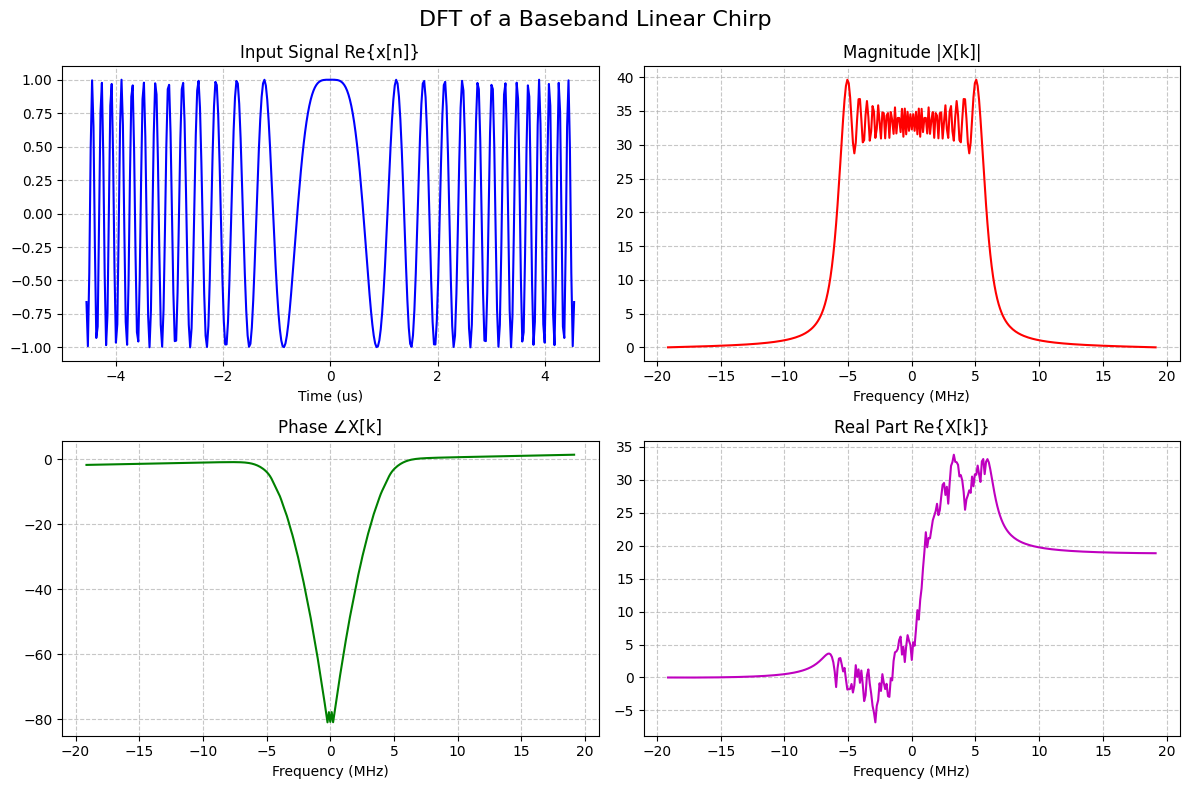

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Parameters
BW = 12e6        # Bandwidth of the chirp (12 MHz)
Tp = 9.09e-6     # Pulse duration (9.09 us)
chirp_rate = BW / Tp  
Fs = 3.2 * BW    # Sampling frequency (13.2 MHz)

# 2. Correct Time Vector
# Number of points = Duration * Sampling Frequency
num_samples = int(Tp * Fs) 
t = np.linspace(-Tp/2, Tp/2, num_samples)

# 3. Correct Chirp Equation (added np.pi)
x = np.exp(1j * np.pi * chirp_rate * t**2) 

# 4. Compute FFT and Shift it to center 0 Hz
y = np.fft.fft(x)
y_shifted = np.fft.fftshift(y)

# 5. Create a proper frequency axis (in MHz for easier reading)
freqs = np.fft.fftshift(np.fft.fftfreq(num_samples, d=1/Fs))
freqs_MHz = freqs / 1e6 

# 6. Plotting
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("DFT of a Baseband Linear Chirp", fontsize=16)

# (1) Input Signal (Real part)
# Plotting against time (us) rather than raw index
ax[0, 0].plot(t * 1e6, np.real(x), 'b')
ax[0, 0].set_title("Input Signal Re{x[n]}")
ax[0, 0].set_xlabel("Time (us)")
ax[0, 0].grid(True, linestyle='--', alpha=0.7)

# (2) Magnitude
ax[0, 1].plot(freqs_MHz, np.abs(y_shifted), 'r')
ax[0, 1].set_title("Magnitude |X[k]|")
ax[0, 1].set_xlabel("Frequency (MHz)")
ax[0, 1].grid(True, linestyle='--', alpha=0.7)

# (3) Phase
ax[1, 0].plot(freqs_MHz, np.unwrap(np.angle(y_shifted)), 'g')
ax[1, 0].set_title("Phase ∠X[k]")
ax[1, 0].set_xlabel("Frequency (MHz)")
ax[1, 0].grid(True, linestyle='--', alpha=0.7)

# (4) Real Part
ax[1, 1].plot(freqs_MHz, np.unwrap(np.real(y_shifted)), 'm')
ax[1, 1].set_title("Real Part Re{X[k]}")
ax[1, 1].set_xlabel("Frequency (MHz)")
ax[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Amplitude before and after FFT

Original amplitude : 5
Raw FFT peak       : 1938.7328573980392
Normalized peak    : 1.8932938060527726
Single-sided peak  : 3.7865876121055453
Peak frequency     : 99.609375 Hz


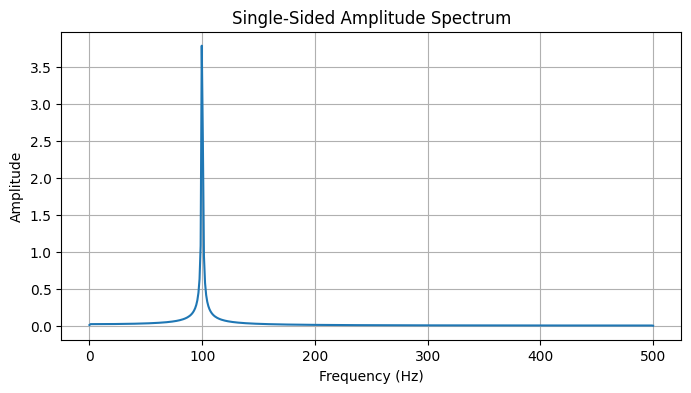

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Fs = 1000          # Sampling frequency (Hz)
N = 1024           # Number of samples
f0 = 100           # Signal frequency (Hz)
A = 5              # Sine wave amplitude

# Time vector
t = np.arange(N) / Fs

# Generate sine wave
x = A * np.sin(2 * np.pi * f0 * t)

# FFT
X = np.fft.fft(x)

# Frequency axis
freq = np.fft.fftfreq(N, d=1/Fs)

# -----------------------------
# Raw FFT magnitude
# -----------------------------
raw_mag = np.abs(X)

# -----------------------------
# Normalized FFT magnitude
# -----------------------------
norm_mag = np.abs(X) / N

# -----------------------------
# Single-sided amplitude spectrum
# -----------------------------
P1 = np.abs(X) / N
P1 = P1[:N//2+1]
P1[1:-1] *= 2

f = np.arange(N//2+1) * Fs / N

# Find peak
peak_index = np.argmax(P1)

print("Original amplitude :", A)
print("Raw FFT peak       :", raw_mag[np.argmax(raw_mag)])
print("Normalized peak    :", norm_mag[np.argmax(norm_mag)])
print("Single-sided peak  :", P1[peak_index])
print("Peak frequency     :", f[peak_index], "Hz")

# Plot
plt.figure(figsize=(8,4))
plt.plot(f, P1)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Single-Sided Amplitude Spectrum")
plt.grid(True)
plt.show()